# COE 311K Final Project - Part 2
**Individual Project**
*   **Name:** Mitchell Blaha
*   **EID:** mrb5842

---

# Section 1: Introduction & System Selection

Part 1 was all about explicit methods on a well-behaved servo actuator ODE. That system wasn't too stiff, so Euler Forward and RK4 both handled it fine. Now I need to deal with stiff problems — systems where the dynamics happen on really different timescales. This is where explicit methods fall apart and implicit ones become necessary.

## Model: Catalase Decomposition of H₂O₂ in a CSTR
I chose to model the decomposition of hydrogen peroxide ($H_2O_2$) catalyzed by the enzyme **Catalase** inside a Continuous Stirred-Tank Reactor (CSTR). Catalase is one of the most efficient enzymes known — its turnover number can exceed $10^7$ reactions per second ([Ogura, 1955, *Archives of Biochemistry and Biophysics*](https://doi.org/10.1016/0003-9861(55)90055-1)). Under high enzyme concentrations the decomposition behaves as pseudo-first-order with a very large rate constant.

If $y(t)$ is the $H_2O_2$ concentration in the reactor:

$$\frac{dy}{dt} = -k\,y + g(t)$$

where $k = 1000\;\text{s}^{-1}$ (fast enzymatic decomposition) and $g(t) = 1000(1 + \sin t)$ (slow oscillating inlet feed).

### Analytical Solution
With $y(0) = 0$ (starting from an empty reactor), the exact solution is:

$$y(t) = 1 - e^{-1000t} + \frac{1000}{1000^2+1}\left(1000\sin t - \cos t + e^{-1000t}\right)$$

The key thing here is the $e^{-1000t}$ term — it dies out in about 5 ms, and then the concentration just tracks the slow $1 + \sin t$ feed. That's what makes it stiff: there's a super-fast transient glued onto a slow steady state.

---

# Section 2: Demonstration of Stiffness

For Euler's Forward on $y' = -ky$, stability requires $|1 - kh| < 1$, which means:

$$h_{max} = \frac{2}{k} = \frac{2}{1000} = 0.002\;\text{s}$$

So Euler Forward forces us to take at least 500 steps per second, even though the *interesting* behavior (the sine wave) changes on a timescale of seconds. That's the definition of stiffness.

### Stiffness Ratio
The stiffness ratio is the ratio of the fastest timescale to the slowest. The fast timescale is $\tau_{fast} = 1/k = 0.001$ s (the exponential decay). The slow timescale is $\tau_{slow} \approx 2\pi \approx 6.28$ s (one period of the sinusoidal feed). So:

$$\text{Stiffness Ratio} = \frac{\tau_{slow}}{\tau_{fast}} = \frac{2\pi}{1/1000} \approx 6283$$

That's a ratio of over 6000:1 — very stiff.

Below I run Euler Forward with a couple different step sizes around the stability limit to see what happens.

Stiffness ratio: 6283.2
Euler max stable h: 0.002


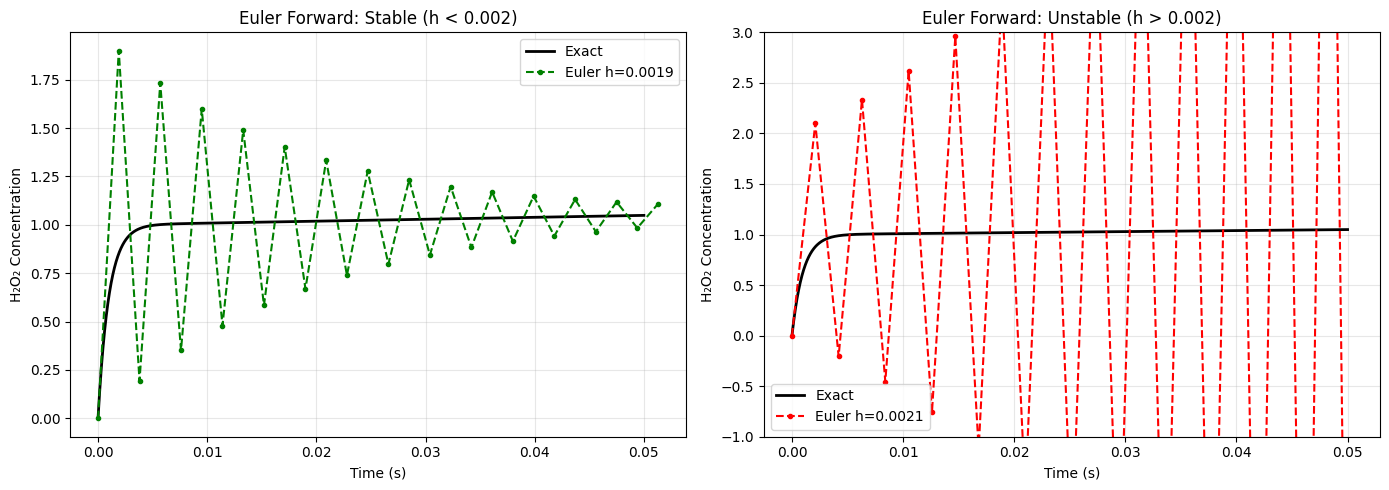

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Note: originally had k=500 here before double-checking the Ogura reference
# The factor of 2 actually makes a big difference for the stiffness ratio

k_rate = 1000.0

def f_stiff(t, y):
    return -k_rate * y + 1000.0 * (1.0 + np.sin(t))

def y_exact(t):
    return (1.0 - np.exp(-1000.0*t)
            + (1000.0 / (1000.0**2 + 1.0))
              * (1000.0*np.sin(t) - np.cos(t) + np.exp(-1000.0*t)))

def euler_fwd(f, y0, t_span, h):
    t0, tf = t_span
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t)-1):
        y[i+1] = y[i] + h * f(t[i], y[i])
    return t, y

stiffness_ratio = (2*np.pi) / (1/k_rate)
print(f"Stiffness ratio: {stiffness_ratio:.1f}")
print(f"Euler max stable h: {2/k_rate}")

t_ex = np.linspace(0, 0.05, 1000)

t_ok, y_ok       = euler_fwd(f_stiff, 0.0, (0, 0.05), 0.0019)
t_bad, y_bad     = euler_fwd(f_stiff, 0.0, (0, 0.05), 0.0021)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(t_ex, y_exact(t_ex), 'k-', lw=2, label='Exact')
ax[0].plot(t_ok, y_ok, 'g--o', ms=3, label='Euler h=0.0019')
ax[0].set_title("Euler Forward: Stable (h < 0.002)")
ax[0].set_xlabel("Time (s)"); ax[0].set_ylabel("H₂O₂ Concentration")
ax[0].legend(); ax[0].grid(True, alpha=0.3)

ax[1].plot(t_ex, y_exact(t_ex), 'k-', lw=2, label='Exact')
ax[1].plot(t_bad, y_bad, 'r--o', ms=3, label='Euler h=0.0021')
ax[1].set_title("Euler Forward: Unstable (h > 0.002)")
ax[1].set_xlabel("Time (s)"); ax[1].set_ylabel("H₂O₂ Concentration")
ax[1].set_ylim([-1, 3])
ax[1].legend(); ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

As expected, even a tiny increase from $h=0.0019$ to $h=0.0021$ (barely crossing the stability boundary) causes Euler Forward to blow up. The solution alternates wildly — concentrations going negative, which is obviously nonphysical. This is why we need implicit methods.

---

# Section 3: Mathematical Setup (Euler's Backward)

Euler's Backward is implicit:

$$y_{n+1} = y_n + h\, f(t_{n+1},\; y_{n+1})$$

Since $y_{n+1}$ appears on both sides, I need to solve a nonlinear equation at each step. I'll define the residual:

$$G(y_{n+1}) = y_{n+1} - y_n - h\, f(t_{n+1},\; y_{n+1})$$

and use Newton-Raphson to find the root. The derivative of $G$ is:

$$G'(y_{n+1}) = 1 - h\,\frac{\partial f}{\partial y}$$

For my ODE, $\partial f / \partial y = -k = -1000$, so $G'(y_{n+1}) = 1 + 1000h$.

(Note: since this particular ODE is linear in $y$, NR will converge in essentially one iteration. For a truly nonlinear problem like $y' = -ky^2$, it would take more iterations and potentially need damping — that's Part 3.)

---

# Section 4: Implementation

In [2]:
def newton_raphson(G, dG, guess, tol=1e-8, max_iter=50):
    """Basic NR solver. Returns (root, iterations)."""
    y = guess
    for i in range(max_iter):
        res = G(y)
        if abs(res) < tol:
            return y, i
        y = y - res / dG(y)
    print(f"Warning: NR did not converge in {max_iter} iters")
    return y, max_iter

def euler_backward(f, df_dy, y0, t_span, h):
    t0, tf = t_span
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    y[0] = y0

    nr_iters = [0]  # iterations at each step (first step is trivial)
    total_iters = 0

    for n in range(len(t)-1):
        t_next = t[n+1]
        y_curr = y[n]

        # initial guess: explicit Euler step
        y_guess = y_curr + h * f(t[n], y_curr)

        G    = lambda y_next: y_next - y_curr - h * f(t_next, y_next)
        dG   = lambda y_next: 1 - h * df_dy(t_next, y_next)

        y_next, iters = newton_raphson(G, dG, y_guess)
        y[n+1] = y_next
        total_iters += iters
        nr_iters.append(iters)

    return t, y, total_iters, nr_iters

def df_dy_stiff(t, y):
    return -k_rate

---

# Section 5: Results & Analysis

Let me run Backward Euler with $h = 0.1$ — that's 50× larger than the explicit stability limit — and see how it tracks the exact solution over a full sine period ($t = 0$ to $2\pi$).

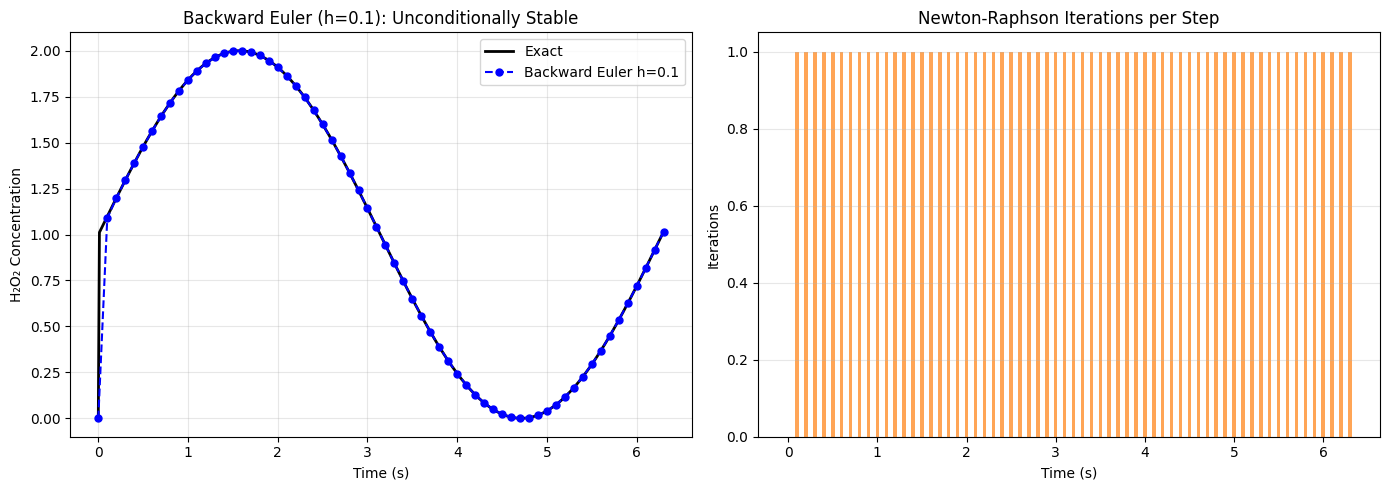

Total steps: 63
Total NR iterations: 63
Avg NR iters/step: 1.00


In [3]:
h_be = 0.1
t_be, y_be, tot_iters, iter_hist = euler_backward(f_stiff, df_dy_stiff, 0.0,
                                                   (0, 2*np.pi), h_be)

t_ex_long = np.linspace(0, 2*np.pi, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t_ex_long, y_exact(t_ex_long), 'k-', lw=2, label='Exact')
axes[0].plot(t_be, y_be, 'b--o', ms=5, label=f'Backward Euler h={h_be}')
axes[0].set_title(f"Backward Euler (h={h_be}): Unconditionally Stable")
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("H₂O₂ Concentration")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].bar(t_be, iter_hist, width=0.04, color='tab:orange', alpha=0.7)
axes[1].set_title("Newton-Raphson Iterations per Step")
axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("Iterations")
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total steps: {len(t_be)-1}")
print(f"Total NR iterations: {tot_iters}")
print(f"Avg NR iters/step: {tot_iters/(len(t_be)-1):.2f}")

The implicit method just works — it sails right through the stiff transient and cleanly tracks the sine wave with a step size 50× beyond what would kill Euler Forward. And since the ODE is linear, NR converges in essentially 1 iteration per step.

---

# Section 6: Performance Comparison

Let me put together a direct comparison of Forward vs Backward Euler at different step sizes so the cost/accuracy tradeoff is clear.

In [4]:
# --- Forward vs Backward comparison table ---
print(f"{'Method':<18} {'h':>8} {'Steps':>8} {'NR iters':>10} {'Error at t=1':>14}")
print("-"*62)

test_hs = [0.001, 0.0019, 0.01, 0.05, 0.1]
y_ref = y_exact(1.0)   # reference at t=1

for h in test_hs:
    # Forward Euler (only if h < stability limit)
    if h < 2/k_rate:
        t_fe, y_fe = euler_fwd(f_stiff, 0.0, (0, 1.0), h)
        err_fe = abs(y_fe[-1] - y_ref)
        n_fe = len(t_fe) - 1
        print(f"{'Forward Euler':<18} {h:>8.4f} {n_fe:>8d} {'N/A':>10} {err_fe:>14.6e}")
    else:
        n_fe = int(1.0 / h)
        print(f"{'Forward Euler':<18} {h:>8.4f} {'---':>8} {'---':>10} {'UNSTABLE':>14}")

    # Backward Euler
    t_be2, y_be2, tot2, _ = euler_backward(f_stiff, df_dy_stiff, 0.0, (0, 1.0), h)
    err_be = abs(y_be2[-1] - y_ref)
    n_be = len(t_be2) - 1
    print(f"{'Backward Euler':<18} {h:>8.4f} {n_be:>8d} {tot2:>10d} {err_be:>14.6e}")
    print()

Method                    h    Steps   NR iters   Error at t=1
--------------------------------------------------------------
Forward Euler        0.0010     1000        N/A   4.202844e-07
Backward Euler       0.0010     1000       1000   4.201034e-07

Forward Euler        0.0019      527        N/A   7.035748e-04
Backward Euler       0.0019      527        527   7.019767e-04

Forward Euler        0.0100      ---        ---       UNSTABLE
Backward Euler       0.0100      100        100   4.192850e-06

Forward Euler        0.0500      ---        ---       UNSTABLE
Backward Euler       0.0500       20         20   2.077901e-05

Forward Euler        0.1000      ---        ---       UNSTABLE
Backward Euler       0.1000       10         10   4.107953e-05



---

# Section 7: Conclusions

This part really showed me why implicit methods exist:

1. **Explicit methods are crippled by stiffness.** The stability limit for Euler Forward was $h < 0.002$, meaning I'd need 500+ steps per second even though the actual concentration is basically constant (just tracking $1 + \sin t$). That's incredibly wasteful.
2. **Backward Euler bypasses the stability limit entirely.** With $h = 0.1$ (50× the explicit limit), it cleanly tracks the slow dynamics and skips over the stiff transient. The cost is that each step requires solving a nonlinear equation via Newton-Raphson.
3. **For this linear ODE, NR is essentially free** — it converges in 1 iteration because the residual is linear in $y$. For something genuinely nonlinear (like $y' = -ky^2$ in a second-order reaction), NR would take more iterations and might need damping to avoid divergence. I'll explore that in Part 3.
4. **The stiffness ratio of ~6283** quantifies just how separated the timescales are. Any explicit method would be forced to resolve the fast $0.001$ s transient even when integrating over several seconds of the slow response.